#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.metrics import classification_report

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jacquelinemcginley/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/jacquelinemcginley/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/jacquelinemcginley/nltk_data...


True

#### Load Data

In [3]:
yelp = pd.read_csv("hotel_final.csv")

yelp.head()

,Unnamed: 0,reviewID,reviewContent,rating,usefulCount,coolCount,funnyCount
0,2982,-ZkzDLAp-6LSdek-nU,My husband took me to stay the night for a fun...,4,0,0,0
1,2983,9yStfyRS5CISu-May43dmA,"stayed at the property over the weekend, got a...",3,0,0,0
2,2984,Wf-7bJszS2n6REXGbrwK2w,"Overall, I think I'm less and less a fan of th...",3,0,0,0
3,2985,ZLe,I'd like to make a confession. I don't really ...,3,21,11,16
4,2986,vURf9AGmThDrRC9TVcQrdw,The good: the view; location The bad: servic...,1,0,0,0


#### Inspect Data

In [4]:
print(yelp.shape)
print(yelp.columns)
yelp.info()
yelp.head()

(949, 7)
Index(['Unnamed: 0', 'reviewID', 'reviewContent', 'rating', 'usefulCount',
       'coolCount', 'funnyCount'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949 entries, 0 to 948
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     949 non-null    int64 
 1   reviewID       949 non-null    object
 2   reviewContent  949 non-null    object
 3   rating         949 non-null    int64 
 4   usefulCount    949 non-null    int64 
 5   coolCount      949 non-null    int64 
 6   funnyCount     949 non-null    int64 
dtypes: int64(5), object(2)
memory usage: 52.0+ KB


,Unnamed: 0,reviewID,reviewContent,rating,usefulCount,coolCount,funnyCount
0,2982,-ZkzDLAp-6LSdek-nU,My husband took me to stay the night for a fun...,4,0,0,0
1,2983,9yStfyRS5CISu-May43dmA,"stayed at the property over the weekend, got a...",3,0,0,0
2,2984,Wf-7bJszS2n6REXGbrwK2w,"Overall, I think I'm less and less a fan of th...",3,0,0,0
3,2985,ZLe,I'd like to make a confession. I don't really ...,3,21,11,16
4,2986,vURf9AGmThDrRC9TVcQrdw,The good: the view; location The bad: servic...,1,0,0,0


#### Check for  Missing Values

In [6]:
yelp.isnull().sum()

Unnamed: 0       0
reviewID         0
reviewContent    0
rating           0
usefulCount      0
coolCount        0
funnyCount       0
dtype: int64

#### Create Sentiment Groups

In [7]:
def sentiment_group(rating):
    if rating >= 4:
        return "Positive"
    elif rating <= 2:
        return "Negative"
    else:
        return "Neutral"

yelp["sentiment_group"] = yelp["rating"].apply(sentiment_group)

yelp["sentiment_group"].value_counts()

sentiment_group
Positive    540
Neutral     207
Negative    202
Name: count, dtype: int64

#### Visualize Rating  Distribution

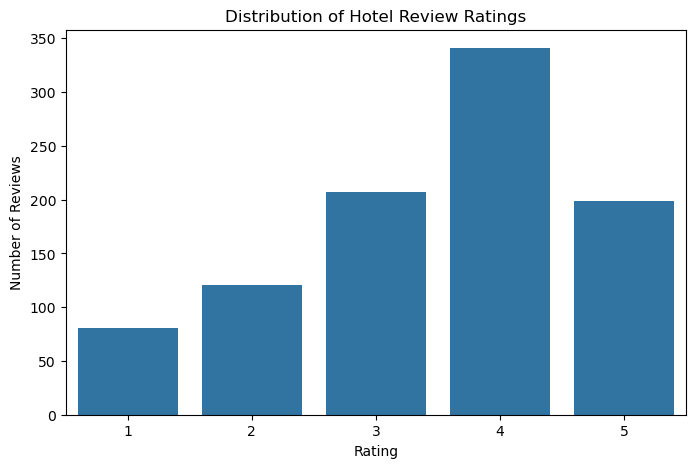

In [9]:
plt.figure(figsize = (8, 5))
sns.countplot(data = yelp, x = "rating")
plt.title("Distribution of Hotel Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

#### Visualize Sentiment Distribution

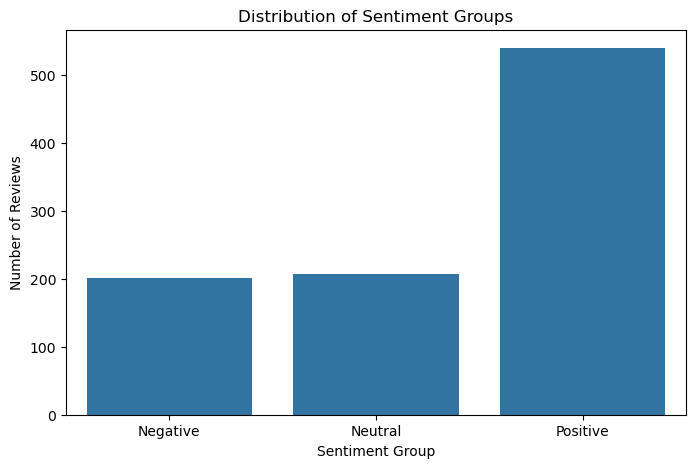

In [10]:
plt.figure(figsize = (8, 5))
sns.countplot(data = yelp, x = "sentiment_group", order=["Negative", "Neutral", "Positive"])
plt.title("Distribution of Sentiment Groups")
plt.xlabel("Sentiment Group")
plt.ylabel("Number of Reviews")
plt.show()